In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

B_RESULTS_CSV_PATH = "B_results.csv"

I_POS_mA = +10.0
I_NEG_mA = -10.0

I_POS_A = I_POS_mA * 1e-3
I_NEG_A = I_NEG_mA * 1e-3

mu0 = 4 * np.pi * 1e-7  # T m / A

# x = magnet line / horizontal image axis
# y = approximate wire direction / vertical image axis
# z = optical axis
# Wire mostly along +y, with possible small tilt toward +x.
# theta = 0° means wire along +y.
# theta > 0° means wire tilts toward +x as y increases

WIRE_THETA_DEG = 5.0
WIRE_X0_UM = 0.0
WIRE_Y0_UM = 0.0

# Effective sensor depth not equal to midpoint necessarly!!!
# It represents the effective distance from the current path to the sensed NV volume
SENSOR_DEPTH_UM = 10.0
SENSOR_Z_SIGN = +1.0

# Finite-width strip model parameters.
# The strip is modeled as many parallel line currents distributed across its width.
STRIP_WIDTH_UM = 20.0
N_STRIP_LINES = 41

B_COMPONENTS = ["Bx", "By", "Bz"]
CMAP = "seismic"


In [28]:
# load B-results fiel

B_df = pd.read_csv(B_RESULTS_CSV_PATH)

required_cols = [
    "pixel", "row", "col", "x_um", "y_um",
    "Bx_pos_nT", "By_pos_nT", "Bz_pos_nT",
    "Bx_neg_nT", "By_neg_nT", "Bz_neg_nT",
]

missing = [c for c in required_cols if c not in B_df.columns]
if missing:
    raise ValueError(f"B_results.csv is missing columns: {missing}")

B_df = B_df.sort_values(["row", "col"]).reset_index(drop=True)

grid_size = int(np.sqrt(len(B_df)))
if grid_size * grid_size != len(B_df):
    raise ValueError("B_results.csv does not contain a square grid.")

x_grid_um = B_df["x_um"].to_numpy().reshape(grid_size, grid_size)
y_grid_um = B_df["y_um"].to_numpy().reshape(grid_size, grid_size)

extent_um = [
    np.nanmin(x_grid_um),
    np.nanmax(x_grid_um),
    np.nanmin(y_grid_um),
    np.nanmax(y_grid_um),
]

B_pos_meas = np.stack([
    B_df["Bx_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_pos_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_neg_meas = np.stack([
    B_df["Bx_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_neg_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

print("Loaded measured data")
print("grid:", grid_size, "x", grid_size)
print("extent_um:", extent_um)

if "POS_time_actual_s" in B_df.columns:
    print("POS time [s]:", B_df["POS_time_actual_s"].iloc[0])
if "NEG_time_actual_s" in B_df.columns:
    print("NEG time [s]:", B_df["NEG_time_actual_s"].iloc[0])


Loaded measured data
grid: 31 x 31
extent_um: [np.float64(-100.0), np.float64(100.0), np.float64(-100.0), np.float64(100.0)]
POS time [s]: 0.0625968
NEG time [s]: 0.0571872


## Infinite straight wire model

SI units internally:
   x,y,z in meters
   I in amperes
   B in tesla 
 Output:  B in nT


In [29]:

def simulate_tilted_wire(
    x_um,
    y_um,
    I_A,
    depth_um,
    x0_um=0.0,
    y0_um=0.0,
    theta_deg=0.0,
    sensor_z_sign=+1.0,
):
    """
    Infinite straight wire in the xy plane.

    Lab frame:
        x = horizontal image axis / magnet line
        y = vertical image axis / approximate wire direction
        z = optical axis

    Wire direction:
        theta_deg = 0 means wire along +y.
        theta_deg > 0 tilts the wire toward +x as y increases.

    sensor_z_sign:
        +1 means sensor plane is evaluated at z = +depth.
        -1 means sensor plane is evaluated at z = -depth.

    Returns:
        B_nT with shape (3, Ny, Nx), order [Bx, By, Bz].
    """

    theta = np.deg2rad(theta_deg)

    ux = np.sin(theta)
    uy = np.cos(theta)
    uz = 0.0

    X = (x_um - x0_um) * 1e-6
    Y = (y_um - y0_um) * 1e-6
    Z = sensor_z_sign * depth_um * 1e-6 * np.ones_like(X)

    Rx = X
    Ry = Y
    Rz = Z

    u_dot_R = ux * Rx + uy * Ry + uz * Rz

    rho_x = Rx - ux * u_dot_R
    rho_y = Ry - uy * u_dot_R
    rho_z = Rz - uz * u_dot_R

    rho2 = rho_x**2 + rho_y**2 + rho_z**2
    rho2 = np.where(rho2 < 1e-30, 1e-30, rho2)

    # u x rho
    cross_x = uy * rho_z - uz * rho_y
    cross_y = uz * rho_x - ux * rho_z
    cross_z = ux * rho_y - uy * rho_x

    prefactor = mu0 * I_A / (2 * np.pi * rho2)

    Bx_T = prefactor * cross_x
    By_T = prefactor * cross_y
    Bz_T = prefactor * cross_z

    return 1e9 * np.stack([Bx_T, By_T, Bz_T], axis=0)

In [30]:
# Finite-width strip-current model
def simulate_tilted_strip(
    x_um,
    y_um,
    I_A,
    depth_um,
    width_um,
    n_lines=41,
    x0_um=0.0,
    y0_um=0.0,
    theta_deg=0.0,
    sensor_z_sign=+1.0,
):
    """
    Finite-width strip current, approximated by many parallel line currents.

    The strip direction is the same as the wire direction:
        theta_deg = 0 means along +y.

    The strip width is distributed along the in-plane perpendicular direction.
    """

    theta = np.deg2rad(theta_deg)

    # Wire direction u = (sin theta, cos theta)
    ux = np.sin(theta)
    uy = np.cos(theta)

    # In-plane perpendicular direction p.
    # If u = (0,1), then p = (1,0), i.e. strip width along x.
    px = uy
    py = -ux

    offsets_um = np.linspace(-width_um / 2, width_um / 2, n_lines)

    B_total = np.zeros((3,) + x_um.shape, dtype=float)

    for offset_um in offsets_um:
        x0_line = x0_um + offset_um * px
        y0_line = y0_um + offset_um * py

        B_line = simulate_tilted_wire(
            x_um=x_um,
            y_um=y_um,
            I_A=I_A / n_lines,
            depth_um=depth_um,
            x0_um=x0_line,
            y0_um=y0_line,
            theta_deg=theta_deg,
            sensor_z_sign=sensor_z_sign,
        )

        B_total += B_line

    return B_total

In [31]:
# ============================================================
# Simulate POS and NEG maps
# ============================================================

# Infinite line-current model
B_pos_sim_line = simulate_tilted_wire(
    x_grid_um,
    y_grid_um,
    I_A=I_POS_A,
    depth_um=SENSOR_DEPTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
    sensor_z_sign=SENSOR_Z_SIGN,
)

B_neg_sim_line = simulate_tilted_wire(
    x_grid_um,
    y_grid_um,
    I_A=I_NEG_A,
    depth_um=SENSOR_DEPTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
    sensor_z_sign=SENSOR_Z_SIGN,
)

# Finite-width strip-current model
B_pos_sim_strip = simulate_tilted_strip(
    x_grid_um,
    y_grid_um,
    I_A=I_POS_A,
    depth_um=SENSOR_DEPTH_UM,
    width_um=STRIP_WIDTH_UM,
    n_lines=N_STRIP_LINES,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
    sensor_z_sign=SENSOR_Z_SIGN,
)

B_neg_sim_strip = simulate_tilted_strip(
    x_grid_um,
    y_grid_um,
    I_A=I_NEG_A,
    depth_um=SENSOR_DEPTH_UM,
    width_um=STRIP_WIDTH_UM,
    n_lines=N_STRIP_LINES,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
    sensor_z_sign=SENSOR_Z_SIGN,
)

print("Simulated POS and NEG maps")

for model_name, B_pos_sim in [
    ("line", B_pos_sim_line),
    ("strip", B_pos_sim_strip),
]:
    print("\nModel:", model_name)
    for i, comp in enumerate(B_COMPONENTS):
        print(comp, "POS p95 [nT] =", np.nanpercentile(np.abs(B_pos_sim[i]), 95))

Simulated POS and NEG maps

Model: line
Bx POS p95 [nT] = 156454.7530930767
By POS p95 [nT] = 13688.017250391704
Bz POS p95 [nT] = 96591.68981865636

Model: strip
Bx POS p95 [nT] = 142151.24248175323
By POS p95 [nT] = 12436.622223278142
Bz POS p95 [nT] = 85272.88536423282


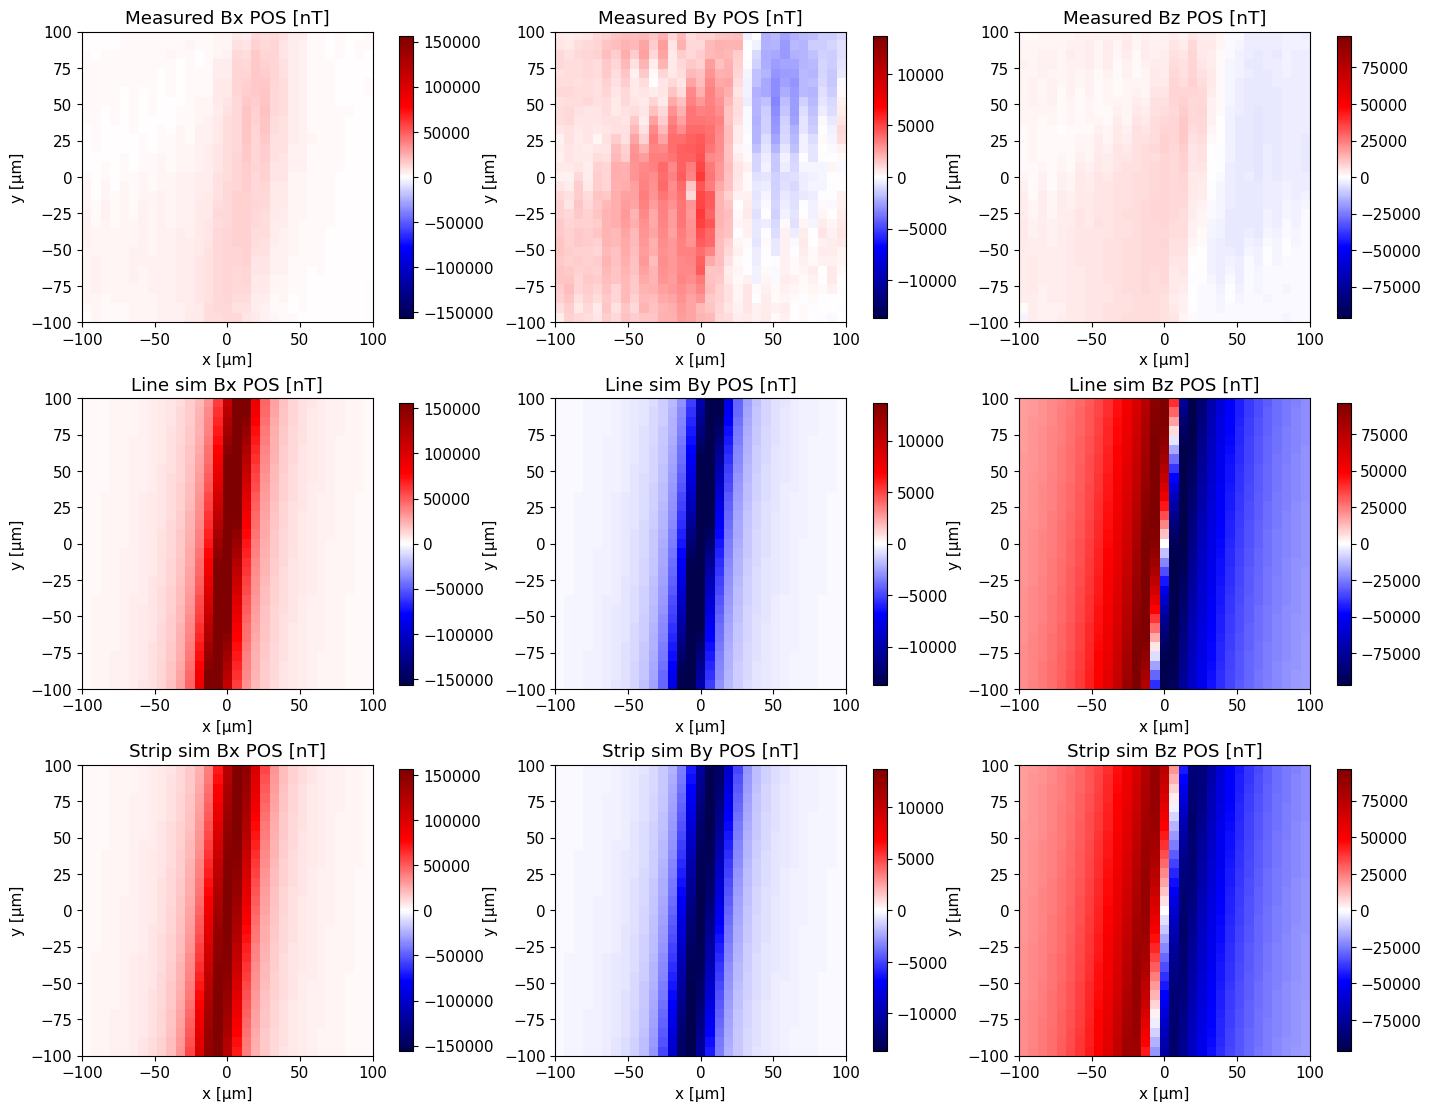

In [32]:
# ============================================================
# Plot measured POS vs simulated POS
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(14, 11), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    lim = max(
        np.nanpercentile(np.abs(B_pos_meas[i]), 95),
        np.nanpercentile(np.abs(B_pos_sim_line[i]), 95),
        np.nanpercentile(np.abs(B_pos_sim_strip[i]), 95),
    )
    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    maps = [
        (B_pos_meas[i], f"Measured {comp} POS [nT]"),
        (B_pos_sim_line[i], f"Line sim {comp} POS [nT]"),
        (B_pos_sim_strip[i], f"Strip sim {comp} POS [nT]"),
    ]

    for row_i, (data, title) in enumerate(maps):
        im = axes[row_i, i].imshow(
            data,
            extent=extent_um,
            origin="lower",
            aspect="equal",
            cmap=CMAP,
            vmin=-lim,
            vmax=lim,
        )
        axes[row_i, i].set_title(title)
        axes[row_i, i].set_xlabel("x [µm]")
        axes[row_i, i].set_ylabel("y [µm]")
        plt.colorbar(im, ax=axes[row_i, i], fraction=0.046, pad=0.04)

plt.show()

In [33]:
# ============================================================
# Direct measured-vs-simulated comparison
# ============================================================

comparison_rows = []

model_dict = {
    "line": (B_pos_sim_line, B_neg_sim_line),
    "strip": (B_pos_sim_strip, B_neg_sim_strip),
}

for model_name, (Bpos_sim, Bneg_sim) in model_dict.items():
    for i, comp in enumerate(B_COMPONENTS):
        for phase, meas_map, sim_map in [
            ("POS", B_pos_meas[i], Bpos_sim[i]),
            ("NEG", B_neg_meas[i], Bneg_sim[i]),
        ]:
            meas = meas_map.ravel()
            sim = sim_map.ravel()

            mask = np.isfinite(meas) & np.isfinite(sim)

            if np.nanstd(meas[mask]) > 0 and np.nanstd(sim[mask]) > 0:
                corr = np.corrcoef(meas[mask], sim[mask])[0, 1]
            else:
                corr = np.nan

            rms_res = np.sqrt(np.nanmean((meas[mask] - sim[mask])**2))

            # Best scalar scale factor for this component/phase.
            # This is diagnostic only; physical current is still fixed at 10 mA.
            denom = np.sum(sim[mask]**2)
            scale = np.sum(meas[mask] * sim[mask]) / denom if denom != 0 else np.nan

            comparison_rows.append({
                "model": model_name,
                "component": comp,
                "phase": phase,
                "measured_p95_abs_nT": np.nanpercentile(np.abs(meas), 95),
                "simulated_p95_abs_nT": np.nanpercentile(np.abs(sim), 95),
                "best_scale_meas_over_sim": scale,
                "effective_current_mA_if_scaled": scale * (I_POS_mA if phase == "POS" else I_NEG_mA),
                "rms_residual_nT": rms_res,
                "corr_meas_sim": corr,
            })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,model,component,phase,measured_p95_abs_nT,simulated_p95_abs_nT,best_scale_meas_over_sim,effective_current_mA_if_scaled,rms_residual_nT,corr_meas_sim
0,line,Bx,POS,13433.715457,156454.753093,0.086765,0.867651,50404.988056,0.674238
1,line,Bx,NEG,24199.039109,156454.753093,0.144994,-1.449941,47489.227575,0.681033
2,line,By,POS,3673.775926,13688.017250,-0.268058,-2.680582,6246.342794,-0.584826
3,line,By,NEG,5308.921674,13688.017250,-0.365269,3.652689,6792.348224,-0.598332
4,line,Bz,POS,7395.124460,96591.689819,0.022779,0.227785,50699.303114,0.318745
5,line,Bz,NEG,13584.200569,96591.689819,0.049244,-0.492441,49508.115360,0.441782
6,strip,Bx,POS,13433.715457,142151.242482,0.097985,0.979847,46511.088788,0.721361
7,strip,Bx,NEG,24199.039109,142151.242482,0.163258,-1.632575,43421.530908,0.724616
8,strip,By,POS,3673.775926,12436.622223,-0.297358,-2.973580,5973.043129,-0.609917
9,strip,By,NEG,5308.921674,12436.622223,-0.407927,4.079270,6539.435904,-0.630038


In [34]:
# ============================================================
# Geometry scan: depth, tilt, and wire x-position
# ============================================================
# Uses direct POS and NEG comparison.
# Fits Bx and Bz only by default.
#
# Why Bx and Bz?
#   A mostly y-directed current should mainly produce Bx and Bz.
#   By can be nonzero in real data due to curvature, return current,
#   frame mixing, or non-ideal current geometry.
# ============================================================

depth_values_um = np.array([20, 30, 40, 50, 75, 100, 125, 150, 200], dtype=float)
theta_values_deg = np.array([-12, -8, -4, 0, 4, 8, 12], dtype=float)
x0_values_um = np.array([-40, -30, -20, -10, 0, 10, 20, 30, 40], dtype=float)
strip_width_values_um = np.array([5, 10, 20, 40, 60], dtype=float)

components_to_fit = [0, 2]  # Bx and Bz

scan_rows = []

for model_name in ["line", "strip"]:
    for depth_um in depth_values_um:
        for theta_deg in theta_values_deg:
            for x0_um in x0_values_um:

                if model_name == "line":
                    Bpos = simulate_tilted_wire(
                        x_grid_um,
                        y_grid_um,
                        I_A=I_POS_A,
                        depth_um=depth_um,
                        x0_um=x0_um,
                        y0_um=WIRE_Y0_UM,
                        theta_deg=theta_deg,
                        sensor_z_sign=SENSOR_Z_SIGN,
                    )

                    Bneg = simulate_tilted_wire(
                        x_grid_um,
                        y_grid_um,
                        I_A=I_NEG_A,
                        depth_um=depth_um,
                        x0_um=x0_um,
                        y0_um=WIRE_Y0_UM,
                        theta_deg=theta_deg,
                        sensor_z_sign=SENSOR_Z_SIGN,
                    )

                    width_um = np.nan

                    models_to_check = [(Bpos, Bneg, width_um)]

                else:
                    models_to_check = []

                    for width_um in strip_width_values_um:
                        Bpos = simulate_tilted_strip(
                            x_grid_um,
                            y_grid_um,
                            I_A=I_POS_A,
                            depth_um=depth_um,
                            width_um=width_um,
                            n_lines=N_STRIP_LINES,
                            x0_um=x0_um,
                            y0_um=WIRE_Y0_UM,
                            theta_deg=theta_deg,
                            sensor_z_sign=SENSOR_Z_SIGN,
                        )

                        Bneg = simulate_tilted_strip(
                            x_grid_um,
                            y_grid_um,
                            I_A=I_NEG_A,
                            depth_um=depth_um,
                            width_um=width_um,
                            n_lines=N_STRIP_LINES,
                            x0_um=x0_um,
                            y0_um=WIRE_Y0_UM,
                            theta_deg=theta_deg,
                            sensor_z_sign=SENSOR_Z_SIGN,
                        )

                        models_to_check.append((Bpos, Bneg, width_um))

                for Bpos, Bneg, width_um in models_to_check:

                    meas_parts = []
                    sim_parts = []

                    for comp_i in components_to_fit:
                        meas_parts.append(B_pos_meas[comp_i].ravel())
                        sim_parts.append(Bpos[comp_i].ravel())

                        meas_parts.append(B_neg_meas[comp_i].ravel())
                        sim_parts.append(Bneg[comp_i].ravel())

                    meas = np.concatenate(meas_parts)
                    sim = np.concatenate(sim_parts)

                    mask = np.isfinite(meas) & np.isfinite(sim)

                    if np.sum(mask) < 10:
                        continue

                    denom = np.sum(sim[mask]**2)
                    scale = np.sum(meas[mask] * sim[mask]) / denom if denom != 0 else np.nan

                    sim_scaled = scale * sim

                    rms_scaled = np.sqrt(np.mean((meas[mask] - sim_scaled[mask])**2))
                    rms_unscaled = np.sqrt(np.mean((meas[mask] - sim[mask])**2))

                    if np.std(meas[mask]) > 0 and np.std(sim[mask]) > 0:
                        corr = np.corrcoef(meas[mask], sim[mask])[0, 1]
                    else:
                        corr = np.nan

                    scan_rows.append({
                        "model": model_name,
                        "depth_um": depth_um,
                        "theta_deg": theta_deg,
                        "x0_um": x0_um,
                        "strip_width_um": width_um,
                        "scale_meas_over_sim": scale,
                        "effective_current_mA_if_scaled": scale * I_POS_mA,
                        "corr_BxBz_POSNEG": corr,
                        "rms_unscaled_BxBz_POSNEG_nT": rms_unscaled,
                        "rms_scaled_BxBz_POSNEG_nT": rms_scaled,
                    })

geometry_scan_df = pd.DataFrame(scan_rows)

geometry_scan_df = geometry_scan_df.sort_values(
    ["rms_scaled_BxBz_POSNEG_nT", "corr_BxBz_POSNEG"],
    ascending=[True, False],
)

display(geometry_scan_df.head(25))

,model,depth_um,theta_deg,x0_um,strip_width_um,scale_meas_over_sim,effective_current_mA_if_scaled,corr_BxBz_POSNEG,rms_unscaled_BxBz_POSNEG_nT,rms_scaled_BxBz_POSNEG_nT
114,line,30.0,8.0,20.0,NaN,0.207417,2.074170,0.848563,23018.209795,3809.873616
1137,strip,30.0,8.0,20.0,5.0,0.207570,2.075703,0.848541,22996.799869,3810.115467
1138,strip,30.0,8.0,20.0,10.0,0.208025,2.080245,0.848464,22933.294710,3810.955463
1139,strip,30.0,8.0,20.0,20.0,0.209759,2.097592,0.848011,22689.512214,3815.898946
123,line,30.0,12.0,20.0,NaN,0.208021,2.080212,0.847918,22920.382216,3816.904366
1182,strip,30.0,12.0,20.0,5.0,0.208174,2.081744,0.847888,22898.930870,3817.239749
1183,strip,30.0,12.0,20.0,10.0,0.208628,2.086280,0.847785,22835.302179,3818.358961
1184,strip,30.0,12.0,20.0,20.0,0.210360,2.103600,0.847229,22591.033790,3824.396600
1140,strip,30.0,8.0,20.0,40.0,0.215636,2.156359,0.844450,21847.018432,3854.405627
825,strip,20.0,8.0,20.0,40.0,0.175895,1.758949,0.843999,27951.534842,3859.244528


In [35]:
# ============================================================
# Plot best geometry from scan
# ============================================================

best = geometry_scan_df.iloc[0]

BEST_MODEL = best["model"]
BEST_DEPTH_UM = float(best["depth_um"])
BEST_THETA_DEG = float(best["theta_deg"])
BEST_X0_UM = float(best["x0_um"])
BEST_WIDTH_UM = best["strip_width_um"]
BEST_SCALE = float(best["scale_meas_over_sim"])

print("Best geometry from scan")
print("-----------------------")
print("model:", BEST_MODEL)
print("depth_um:", BEST_DEPTH_UM)
print("theta_deg:", BEST_THETA_DEG)
print("x0_um:", BEST_X0_UM)
print("strip_width_um:", BEST_WIDTH_UM)
print("scale_meas_over_sim:", BEST_SCALE)
print("effective current [mA] if interpreted as scale:", BEST_SCALE * I_POS_mA)

if BEST_MODEL == "line":
    B_pos_best = simulate_tilted_wire(
        x_grid_um,
        y_grid_um,
        I_A=I_POS_A,
        depth_um=BEST_DEPTH_UM,
        x0_um=BEST_X0_UM,
        y0_um=WIRE_Y0_UM,
        theta_deg=BEST_THETA_DEG,
        sensor_z_sign=SENSOR_Z_SIGN,
    )

    B_neg_best = simulate_tilted_wire(
        x_grid_um,
        y_grid_um,
        I_A=I_NEG_A,
        depth_um=BEST_DEPTH_UM,
        x0_um=BEST_X0_UM,
        y0_um=WIRE_Y0_UM,
        theta_deg=BEST_THETA_DEG,
        sensor_z_sign=SENSOR_Z_SIGN,
    )

else:
    B_pos_best = simulate_tilted_strip(
        x_grid_um,
        y_grid_um,
        I_A=I_POS_A,
        depth_um=BEST_DEPTH_UM,
        width_um=float(BEST_WIDTH_UM),
        n_lines=N_STRIP_LINES,
        x0_um=BEST_X0_UM,
        y0_um=WIRE_Y0_UM,
        theta_deg=BEST_THETA_DEG,
        sensor_z_sign=SENSOR_Z_SIGN,
    )

    B_neg_best = simulate_tilted_strip(
        x_grid_um,
        y_grid_um,
        I_A=I_NEG_A,
        depth_um=BEST_DEPTH_UM,
        width_um=float(BEST_WIDTH_UM),
        n_lines=N_STRIP_LINES,
        x0_um=BEST_X0_UM,
        y0_um=WIRE_Y0_UM,
        theta_deg=BEST_THETA_DEG,
        sensor_z_sign=SENSOR_Z_SIGN,
    )

B_pos_best_scaled = BEST_SCALE * B_pos_best
B_neg_best_scaled = BEST_SCALE * B_neg_best

Best geometry from scan
-----------------------
model: line
depth_um: 30.0
theta_deg: 8.0
x0_um: 20.0
strip_width_um: nan
scale_meas_over_sim: 0.20741697249780927
effective current [mA] if interpreted as scale: 2.0741697249780926


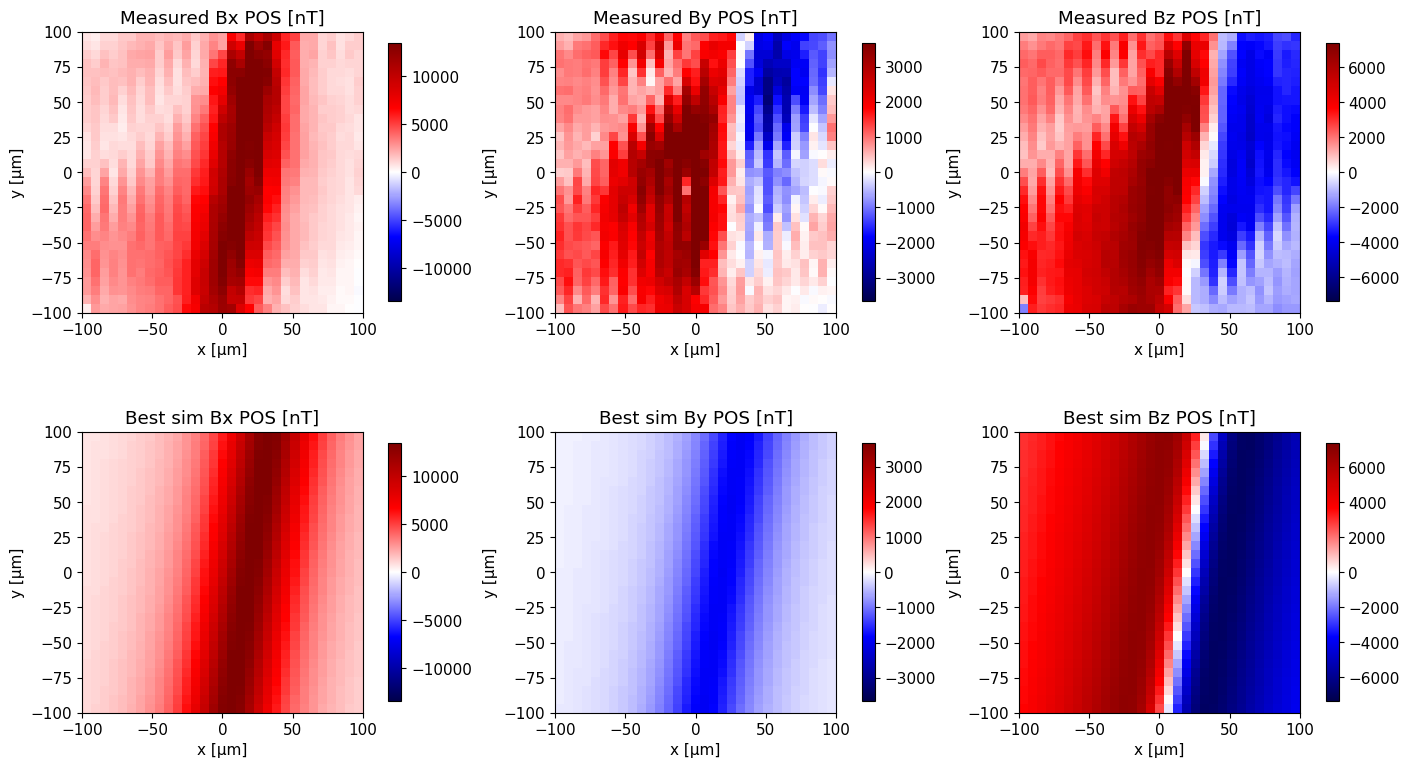

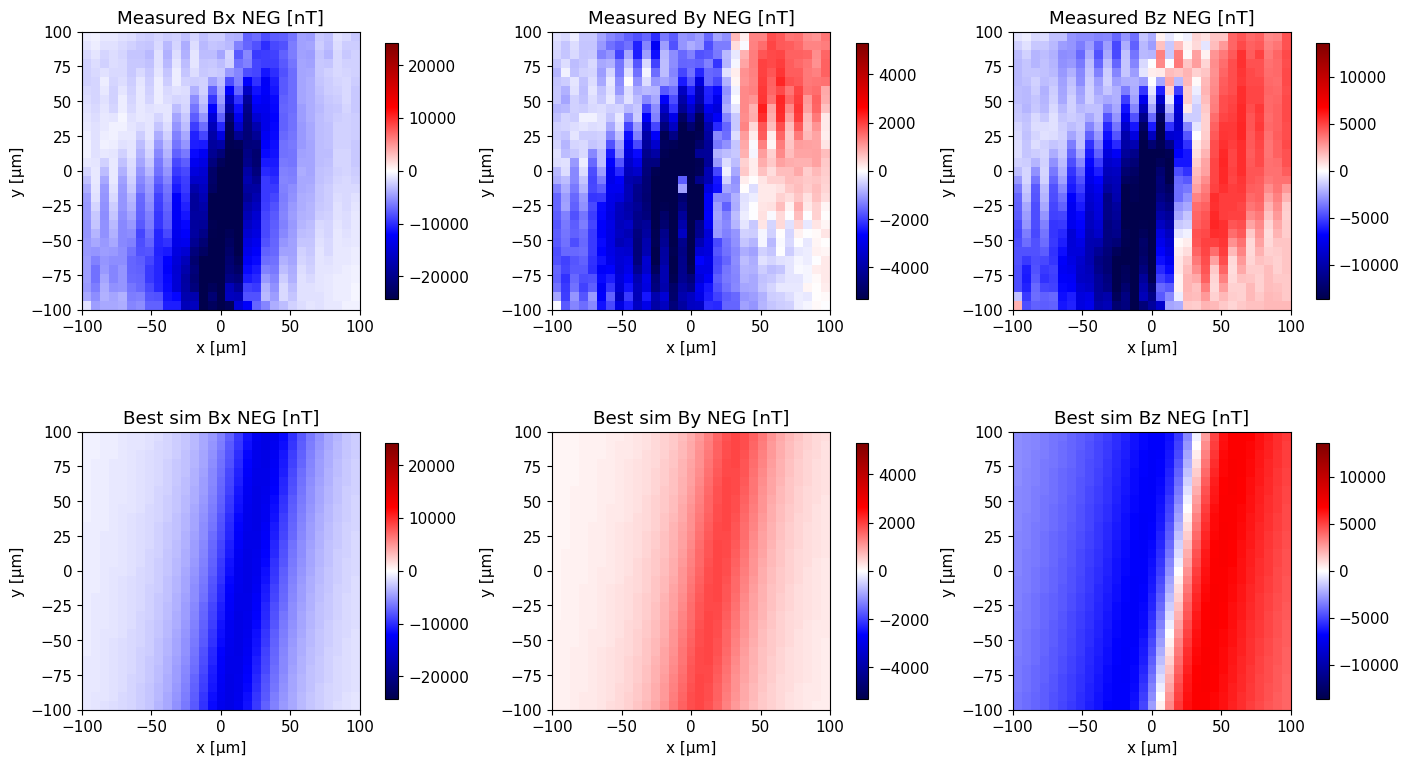

In [37]:
# ============================================================
# Plot measured POS vs best scaled simulation
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    lim = max(
        np.nanpercentile(np.abs(B_pos_meas[i]), 95),
        np.nanpercentile(np.abs(B_pos_best_scaled[i]), 95),
    )
    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im0 = axes[0, i].imshow(
        B_pos_meas[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[0, i].set_title(f"Measured {comp} POS [nT]")
    axes[0, i].set_xlabel("x [µm]")
    axes[0, i].set_ylabel("y [µm]")
    plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

    im1 = axes[1, i].imshow(
        B_pos_best_scaled[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[1, i].set_title(f"Best sim {comp} POS [nT]")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.show()

# ============================================================
# Plot measured NEG vs best scaled simulation
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    lim = max(
        np.nanpercentile(np.abs(B_neg_meas[i]), 95),
        np.nanpercentile(np.abs(B_neg_best_scaled[i]), 95),
    )
    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im0 = axes[0, i].imshow(
        B_neg_meas[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[0, i].set_title(f"Measured {comp} NEG [nT]")
    axes[0, i].set_xlabel("x [µm]")
    axes[0, i].set_ylabel("y [µm]")
    plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

    im1 = axes[1, i].imshow(
        B_neg_best_scaled[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[1, i].set_title(f"Best sim {comp} NEG [nT]")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.show()

In [38]:
# ============================================================
# Comparison table for best scaled simulation
# ============================================================

best_comparison_rows = []

for i, comp in enumerate(B_COMPONENTS):
    for phase, meas_map, sim_map in [
        ("POS", B_pos_meas[i], B_pos_best_scaled[i]),
        ("NEG", B_neg_meas[i], B_neg_best_scaled[i]),
    ]:
        meas = meas_map.ravel()
        sim = sim_map.ravel()

        mask = np.isfinite(meas) & np.isfinite(sim)

        if np.nanstd(meas[mask]) > 0 and np.nanstd(sim[mask]) > 0:
            corr = np.corrcoef(meas[mask], sim[mask])[0, 1]
        else:
            corr = np.nan

        rms_res = np.sqrt(np.nanmean((meas[mask] - sim[mask])**2))

        best_comparison_rows.append({
            "component": comp,
            "phase": phase,
            "measured_p95_abs_nT": np.nanpercentile(np.abs(meas), 95),
            "best_sim_scaled_p95_abs_nT": np.nanpercentile(np.abs(sim), 95),
            "rms_residual_nT": rms_res,
            "corr_meas_best_sim": corr,
        })

best_comparison_df = pd.DataFrame(best_comparison_rows)
display(best_comparison_df)

,component,phase,measured_p95_abs_nT,best_sim_scaled_p95_abs_nT,rms_residual_nT,corr_meas_best_sim
0,Bx,POS,13433.715457,13254.213455,2150.283464,0.879629
1,Bx,NEG,24199.039109,13254.213455,5392.085599,0.748817
2,By,POS,3673.775926,1862.758222,2414.331106,-0.094839
3,By,NEG,5308.921674,1862.758222,3064.913316,-0.219168
4,Bz,POS,7395.124460,6884.531709,3000.273399,0.855660
5,Bz,NEG,13584.200569,6884.531709,3919.260302,0.796320
